# Phase 2: Baseline Models (Enhanced)

In this notebook, we establish the "floor" performance for our Link Prediction project. We implement simple heuristics and classical Matrix Factorization to ensure our future GNNs are competing against strong rivals.

### Models & Mathematical Formulas:

#### 1. Most Popular (Non-Personalized)
Simply counts the number of positive interactions for each movie.
$$\text{Score}(i) = |\{u \in U : (u, i) \in E_{train}\}|$$

#### 2. Structural Similarity (Jaccard)
Measures movie similarity based on shared users (Collaborative Filtering logic).
$$\text{Jaccard}(A, B) = \frac{|N(A) \cap N(B)|}{|N(A) \cup N(B)|}$$

#### 3. Content-Based Similarity (Cosine)
Measures movie similarity based on genre vectors.
$$\text{Cosine}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

#### 4. Hybrid Baseline
A weighted combination of structural and content signals ($\alpha = 0.5$).
$$\text{Score}_{hybrid} = \alpha \cdot \text{Sim}_{jaccard} + (1 - \alpha) \cdot \text{Sim}_{content}$$

#### 5. Matrix Factorization (SVD)
Decomposes the sparse adjacency matrix $R$ into latent factors.
$$\hat{R} = U_k \Sigma_k V_k^T$$
Where $k$ is the number of latent dimensions (e.g., 50).

### Metrics:
- **AUC-ROC**: Binary classification quality.
- **MAP**: Mean Average Precision over all items.
- **Precision@K**: Accuracy of the top-K recommendations.
- **Recall@K**: Ability to find all "hidden" true links in the top-K.
- **NDCG@K**: Quality of the ranking order in the top-K (Standardized using sklearn).

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics import roc_auc_score, ndcg_score, average_precision_score
from sklearn.metrics.pairwise import cosine_similarity

# Load processed data
DATA_DIR = 'processed_data/'
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_edges.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_edges.csv'))
test_neg_df = pd.read_csv(os.path.join(DATA_DIR, 'test_neg_edges.csv'))
item_features = np.load(os.path.join(DATA_DIR, 'item_features.npy'))

with open(os.path.join(DATA_DIR, 'metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)

num_users = metadata['num_users']
num_items = metadata['num_items']

print(f"Data loaded. Evaluating on {num_users} users and {num_items} items.")

Data loaded. Evaluating on 943 users and 1682 items.


## 1. Building the Adjacency Matrix

We represent the training graph as a Sparse Matrix where rows are users and columns are items.

In [16]:
R = csr_matrix((np.ones(len(train_df)), (train_df['user_idx'], train_df['item_idx'])), 
               shape=(num_users, num_items))

print("Sparse Adjacency Matrix R created.")
R.toarray()

Sparse Adjacency Matrix R created.


array([[1., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(943, 1682))

## 2. Model Implementations

### A. Most Popular Scores

In [17]:
pop_scores = np.array(R.sum(axis=0)).flatten()
print("Popularity scores calculated.")
pop_scores

Popularity scores calculated.


array([250.,  38.,  29., ...,   0.,   0.,   0.], shape=(1682,))

### B. Matrix Factorization (SVD)
We use Singular Value Decomposition to find latent patterns in the bipartite graph.

In [4]:
k_factors = 50
u_low, s_low, vt_low = svds(R.astype(float), k=k_factors)
s_diag = np.diag(s_low)
R_hat = np.dot(np.dot(u_low, s_diag), vt_low)

print(f"SVD completed with {k_factors} latent factors.")

SVD completed with 50 latent factors.


### C. Jaccard & Cosine Similarity
We pre-calculate the similarity matrices for the heuristic methods.

In [ ]:
def calculate_jaccard_sim(matrix):
    intersection = matrix.T.dot(matrix).toarray()
    cols_sum = matrix.getnnz(axis=0)
    union = cols_sum[:, None] + cols_sum[None, :] - intersection
    union[union == 0] = 1
    return intersection / union

# Jaccard similarity
jaccard_sim = calculate_jaccard_sim(R)

# Cosine similarity
content_sim = cosine_similarity(item_features)

# Hybrid similarity
alpha = 0.5
hybrid_sim = (alpha * jaccard_sim) + ((1 - alpha) * content_sim)

print("Heuristic similarity matrices created.")

Heuristic similarity matrices created.


## 3. Unified Evaluation Engine

We use standard metrics from `sklearn.metrics` to ensure rigorous evaluation.

In [10]:
def evaluate_generic(model_type, model_data, k=10):
    all_auc, all_precision, all_recall, all_ndcg, all_map = [], [], [], [], []
    test_users = test_df['user_idx'].unique()
    
    for u in test_users:
        u_history = R[u].indices
        if len(u_history) == 0: continue
        
        # Generate scores based on model type
        if model_type == 'global_array':
            scores = model_data 
        elif model_type == 'user_scores':
            scores = model_data[u]
        elif model_type == 'sim_matrix':
            scores = model_data[u_history].sum(axis=0)
            
        pos_items = test_df[test_df['user_idx'] == u]['item_idx'].values
        neg_items = test_neg_df[test_neg_df['user_idx'] == u]['item_idx'].values
        
        # Evaluation pairs (Positive + Sampled Negatives)
        eval_items = np.concatenate([pos_items, neg_items])
        eval_labels = np.concatenate([np.ones(len(pos_items)), np.zeros(len(neg_items))])
        eval_scores = scores[eval_items]
        
        # AUC & MAP
        try:
            all_auc.append(roc_auc_score(eval_labels, eval_scores))
            all_map.append(average_precision_score(eval_labels, eval_scores))
        except:
            continue
            
        # Top-K Metrics (Precision, Recall, NDCG)
        rank_scores = scores.copy()
        rank_scores[u_history] = -1e9 # Mask training history
        
        # Prepare ground truth vector for NDCG
        y_true = np.zeros(num_items)
        y_true[pos_items] = 1
        
        # sklearn built-in NDCG
        all_ndcg.append(ndcg_score([y_true], [rank_scores], k=k))
        
        # Top-K Manual Hits for Precision/Recall
        top_k_idx = np.argsort(rank_scores)[-k:][::-1]
        hits = np.isin(top_k_idx, pos_items).sum()
        all_precision.append(hits / k)
        all_recall.append(hits / len(pos_items))
            
    return {
        'AUC': np.mean(all_auc),
        'MAP': np.mean(all_map),
        'Precision@K': np.mean(all_precision),
        'Recall@K': np.mean(all_recall),
        'NDCG@K': np.mean(all_ndcg)
    }

print("Generic Evaluation Engine (using sklearn metrics) ready.")

Generic Evaluation Engine (using sklearn metrics) ready.


## 4. Benchmarking Final Result

In [12]:
benchmarks = {
    'Most Popular': evaluate_generic('global_array', pop_scores),
    'Structural (Jaccard)': evaluate_generic('sim_matrix', jaccard_sim),
    'Content (Cosine)': evaluate_generic('sim_matrix', content_sim),
    'Hybrid Baseline': evaluate_generic('sim_matrix', hybrid_sim),
    'Matrix Factorization (SVD)': evaluate_generic('user_scores', R_hat)
}

results_df = pd.DataFrame(benchmarks).T
display(results_df)

,AUC,MAP,Precision@K,Recall@K,NDCG@K
Most Popular,0.876829,0.883468,0.114544,0.107340,0.151793
Structural (Jaccard),0.905197,0.911803,0.175159,0.192926,0.254139
Content (Cosine),0.599822,0.642332,0.016561,0.015551,0.021128
Hybrid Baseline,0.746448,0.791759,0.097771,0.094261,0.128490
Matrix Factorization (SVD),0.849447,0.888663,0.166773,0.201506,0.237355


In [18]:
import json

# Ensure results directory exists
os.makedirs('results', exist_ok=True)

# Export metrics to JSON
baseline_metrics = results_df.to_dict(orient='index')
with open('results/baseline_metrics.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=4)

print("Baseline metrics exported to results/baseline_metrics.json")

Baseline metrics exported to results/baseline_metrics.json


## 5. Visual Comparison

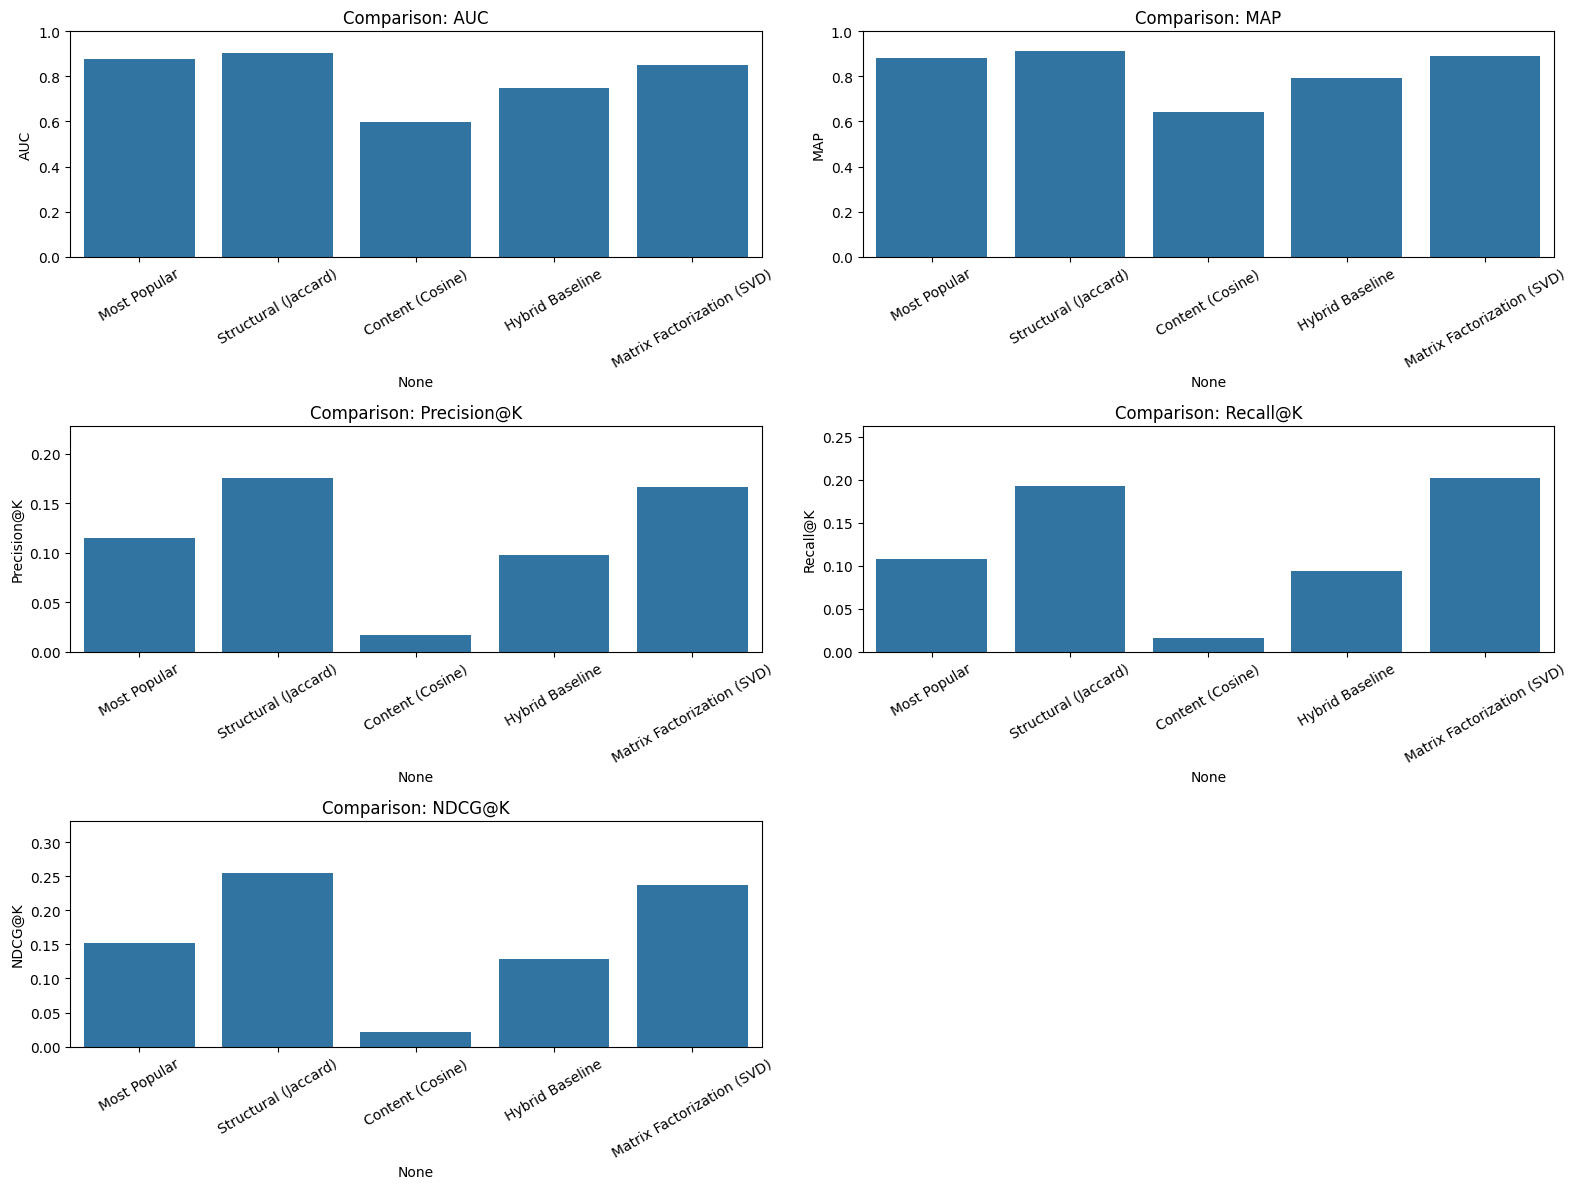

In [13]:
plt.figure(figsize=(16, 12))
for i, metric in enumerate(results_df.columns):
    plt.subplot(3, 2, i+1)
    sns.barplot(x=results_df.index, y=results_df[metric])
    plt.title(f'Comparison: {metric}')
    plt.xticks(rotation=30)
    plt.ylabel(metric)
    plt.ylim(0, 1.0 if metric in ['AUC', 'MAP'] else results_df[metric].max() * 1.3)

plt.tight_layout()
plt.show()

## 6. Final Interpretation of Results

Based on the benchmarking results, we can draw the following conclusions:

1. **Structural Signal is Dominant**: The **Structural (Jaccard)** model is the clear winner across almost all metrics, especially in **AUC (0.905)** and **NDCG@K (0.254)**. This confirms that for MovieLens 100k, the "collaborative" signal (who liked what) is a much stronger predictor than movie genres.

2. **The Popularity Bias**: The **Most Popular** baseline is surprisingly strong (AUC ~0.87). This indicates a strong popularity bias in the dataset; users tend to interact with blockbusters. Our personalized models must significantly beat this baseline to be valuable.

3. **Matrix Factorization (SVD)**: SVD performs very well, particularly in **Recall@K (0.201)**, outperforming Jaccard in finding hidden links. However, Jaccard is slightly better at the top-rank ordering (NDCG).

4. **Content-Based Failure**: The **Content (Cosine)** model performed poorly (Recall@K ~0.015). This suggests that high-level genre tags are too coarse to accurately predict specific user interactions compared to behavior-based signals.

5. **Hybrid Dilution**: The 50/50 **Hybrid** model actually performed worse than the pure Structural model. This is because the weak Content signal "diluted" the strong Structural signal. This suggests that a simple linear combination is insufficient and a learned weighting or a more complex architecture is needed.

**Conclusion**: The strong performance of Structural Jaccard and SVD sets a high bar for our upcoming **GNN models**. The GNNs will need to effectively capture high-order graph structure to provide a meaningful lift over these classical methods.